Data was sourced from [Redfin Housing Market Data](https://www.redfin.com/news/data-center/)
- downloaded at a county level
Data definitions can be found [here](https://www.redfin.com/news/data-center-metrics-definitions/)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/RDC_Inventory_Core_Metrics_County_History.csv")
print(df.head())

   month_date_yyyymm  county_fips           county_name  median_listing_price  \
0             202603        30003          big horn, mt              283750.0   
1             202603        48193          hamilton, tx              276200.0   
2             202603        47177            warren, tn              311850.0   
3             202603        22121  west baton rouge, la              277500.0   
4             202603        49027           millard, ut              384725.0   

   median_listing_price_mm  median_listing_price_yy  active_listing_count  \
0                   0.0480                  -0.1133                    28   
1                   0.0045                  -0.0677                    70   
2                   0.0260                  -0.0688                   206   
3                  -0.0071                   0.0874                    55   
4                   0.0124                   0.0124                    50   

   active_listing_count_mm  active_listing_count_y

In [6]:
df['month'] = pd.to_datetime(df['month_date_yyyymm'], format='%Y%m')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363161 entries, 0 to 363160
Data columns (total 47 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   month_date_yyyymm                        363161 non-null  int64         
 1   county_fips                              363161 non-null  int64         
 2   county_name                              363161 non-null  object        
 3   median_listing_price                     363136 non-null  float64       
 4   median_listing_price_mm                  325663 non-null  float64       
 5   median_listing_price_yy                  324331 non-null  float64       
 6   active_listing_count                     363161 non-null  int64         
 7   active_listing_count_mm                  325592 non-null  float64       
 8   active_listing_count_yy                  324170 non-null  float64       
 9   median_days_on_market     

In [7]:
print(df.columns)

Index(['month_date_yyyymm', 'county_fips', 'county_name',
       'median_listing_price', 'median_listing_price_mm',
       'median_listing_price_yy', 'active_listing_count',
       'active_listing_count_mm', 'active_listing_count_yy',
       'median_days_on_market', 'median_days_on_market_mm',
       'median_days_on_market_yy', 'new_listing_count', 'new_listing_count_mm',
       'new_listing_count_yy', 'price_increased_count',
       'price_increased_count_mm', 'price_increased_count_yy',
       'price_increased_share', 'price_increased_share_mm',
       'price_increased_share_yy', 'price_reduced_count',
       'price_reduced_count_mm', 'price_reduced_count_yy',
       'price_reduced_share', 'price_reduced_share_mm',
       'price_reduced_share_yy', 'pending_listing_count',
       'pending_listing_count_mm', 'pending_listing_count_yy',
       'median_listing_price_per_square_foot',
       'median_listing_price_per_square_foot_mm',
       'median_listing_price_per_square_foot_yy', 'medi

In [8]:
butte_df = df[df['county_name'] == 'butte, ca']
print(butte_df.head())

       month_date_yyyymm  county_fips county_name  median_listing_price  \
617               202603         6007   butte, ca              422625.0   
3860              202602         6007   butte, ca              425000.0   
8059              202601         6007   butte, ca              429000.0   
10160             202512         6007   butte, ca              421200.0   
13338             202511         6007   butte, ca              419450.0   

       median_listing_price_mm  median_listing_price_yy  active_listing_count  \
617                    -0.0056                  -0.0102                   485   
3860                   -0.0093                   0.0252                   463   
8059                    0.0185                   0.0095                   445   
10160                   0.0042                  -0.0085                   500   
13338                  -0.0060                  -0.0243                   582   

       active_listing_count_mm  active_listing_count_yy  \
617

In [9]:
shasta_df = df[df['county_name'] == 'shasta, ca']
print(shasta_df.head())

       month_date_yyyymm  county_fips county_name  median_listing_price  \
997               202603         6089  shasta, ca              440500.0   
3385              202602         6089  shasta, ca              420975.0   
7076              202601         6089  shasta, ca              424950.0   
10112             202512         6089  shasta, ca              425000.0   
14753             202511         6089  shasta, ca              434900.0   

       median_listing_price_mm  median_listing_price_yy  active_listing_count  \
997                     0.0464                   0.0268                   520   
3385                   -0.0094                   0.0168                   472   
7076                   -0.0001                   0.0191                   468   
10112                  -0.0228                   0.0131                   527   
14753                   0.0185                   0.0185                   615   

       active_listing_count_mm  active_listing_count_yy  \
997

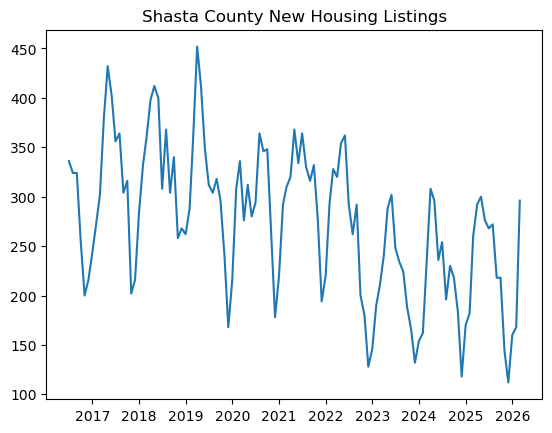

In [10]:
plt.plot(shasta_df['month'], shasta_df['new_listing_count'])
plt.title('Shasta County New Housing Listings')
plt.show()

Text(0.5, 1.0, 'Butte County New Housing Listings')

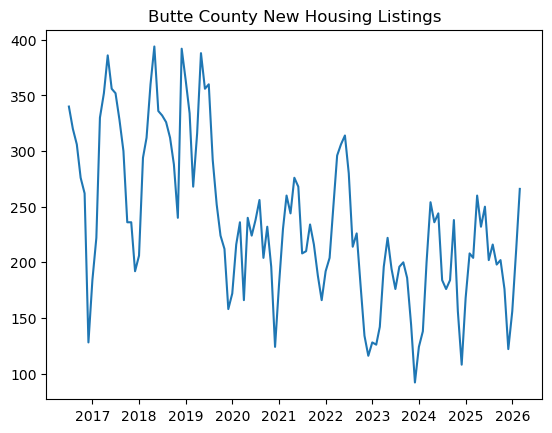

In [11]:
plt.plot(butte_df['month'], butte_df['new_listing_count'])
plt.title('Butte County New Housing Listings')

In [12]:
# filtered by moth for the 
shasta_filtered = shasta_df[shasta_df['month'].between('2018-01', '2020-01')]
butte_filtered = butte_df[butte_df['month'].between('2018-01', '2020-01')]
print(shasta_filtered.shape)
print(butte_filtered.shape)

(25, 47)
(25, 47)


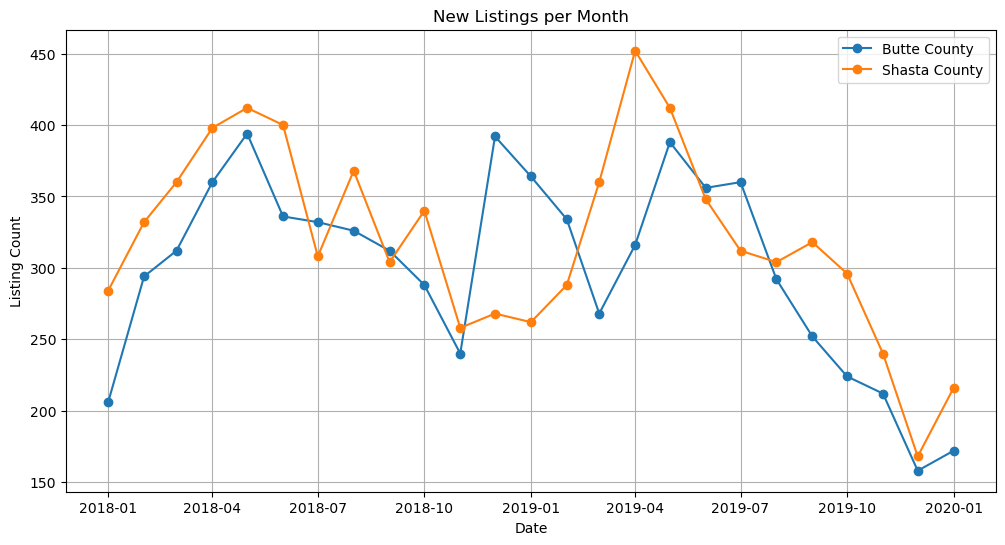

In [21]:
# plotting new listings per month for both counties
plt.figure(figsize=(12, 6))
plt.plot('month', 'new_listing_count', data=butte_filtered, label='Butte County', marker='o')
plt.plot('month', 'new_listing_count', data=shasta_filtered, label='Shasta County', marker='o')
plt.title('New Listings per Month')
plt.xlabel('Date')
plt.ylabel('Listing Count')
plt.grid(True)
plt.legend()
plt.show()

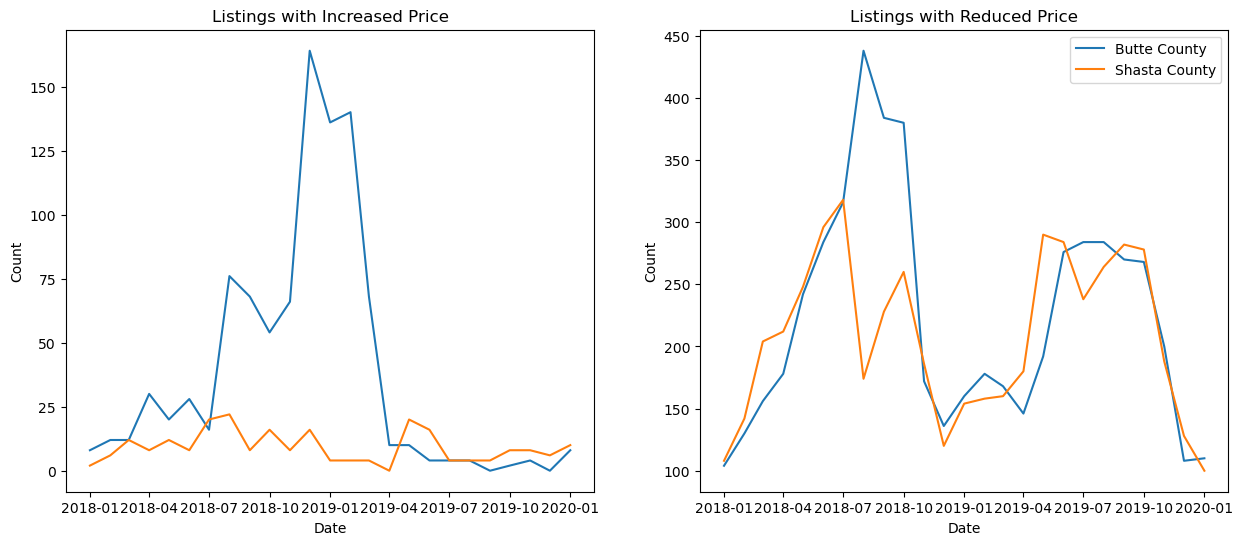

In [14]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))
ax1.plot('month', 'price_increased_count', data=butte_filtered, label='Butte County')
ax1.plot('month', 'price_increased_count', data=shasta_filtered, label='Shasta County')
ax1.set_title('Listings with Increased Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Count')
#.legend()

ax2.plot('month', 'price_reduced_count', data=butte_filtered, label='Butte County')
ax2.plot('month', 'price_reduced_count', data=shasta_filtered, label='Shasta County')
ax2.set_title('Listings with Reduced Price')
ax2.set_xlabel('Date')
ax2.set_ylabel('Count')
plt.legend()
plt.show()

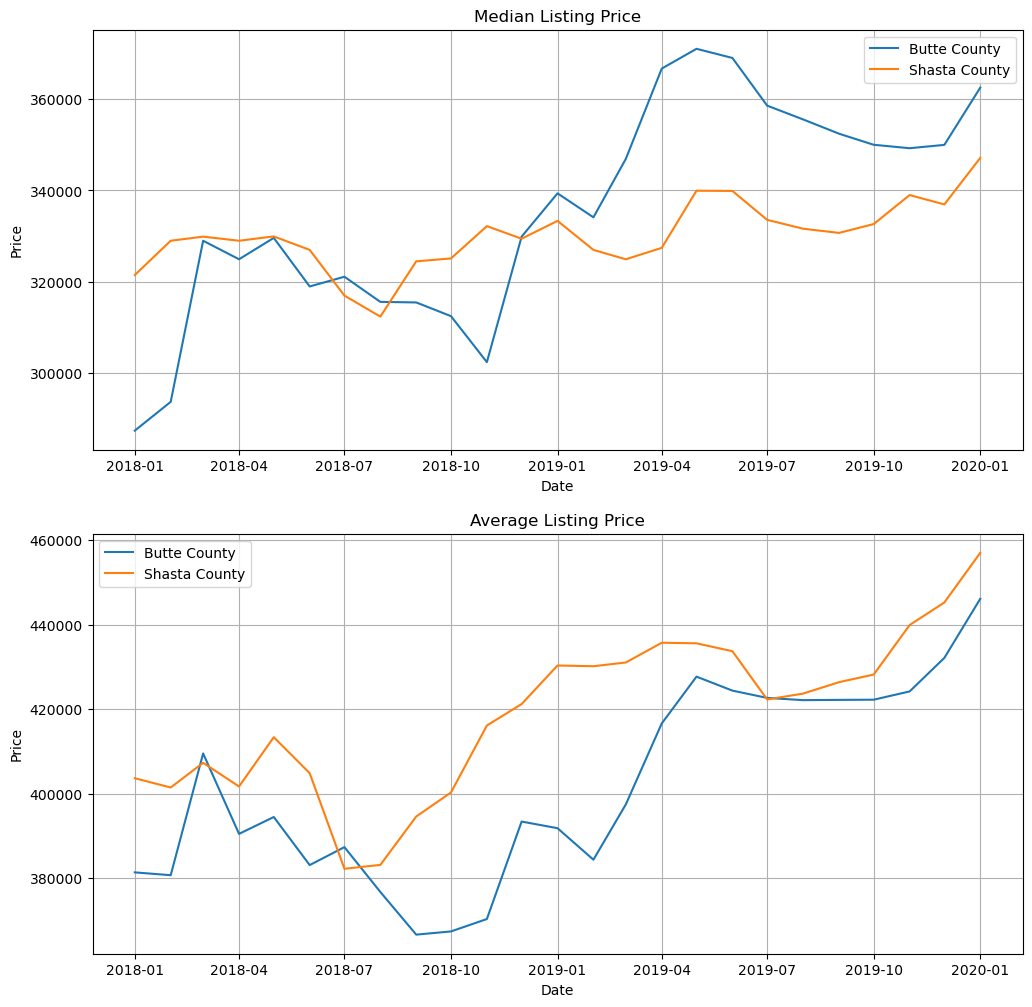

In [25]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 12))
# plt.figure(figsize=(12, 6))
ax1.plot('month', 'median_listing_price', data=butte_filtered, label='Butte County')
ax1.plot('month', 'median_listing_price', data=shasta_filtered, label='Shasta County')
ax1.set_title('Median Listing Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True)

ax2.plot('month', 'average_listing_price', data=butte_filtered, label='Butte County')
ax2.plot('month', 'average_listing_price', data=shasta_filtered, label='Shasta County')
ax2.set_title('Average Listing Price')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price')
ax2.grid(True)
plt.legend()
plt.show()